In [1]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import pycea as py

import scanpy as sc
from anndata import AnnData
import treedata as td
from fastrna.core import fastrna_hvg, fastrna_pca
import sys
sys.path.append("/project/imoskowitz/yubin/Lineage_Tree_Construction/Cross_Time_Point_Tree_Construction")
from Moslin.utility import matrixfy_character_obsm

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [2]:
sys.path.append("/project/imoskowitz/yubin/Lineage_Tree_Construction")
from lineage_utilities.tree_functions import *

In [2]:
%load_ext autoreload
%autoreload 2



Early run, only **first replicate** is used. Since there are also multiple clones in the replicate, I will take the clone with the biggest lineage tree and as a result should probably subset the data before we concat. 
TODO: Figure out why there are multiple clones. Why the nodes in the tree and the clone cell count do not match up 
TODO: Create cost matrix for each time point, and the cost matrix 
TODO: Use Gene Expression for cost matrix across time points 

### Data loading and Merging


In [3]:
from pathlib import Path
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"

In [53]:
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
tdatas = {}
for file_path in Lineage_data.glob("*.h5td"): # Taking only the first replicate

    #tdatas[file_path.stem] = td.read_h5td(file_path)

    # For testing, extract only timepoint lower than E9.0
    # Extract stage from filename (e.g., "E8.5-R1" from "E8.5-R1-C1.h5td")
    stem = file_path.stem
    stage = stem.split("-")[0]  # Extract "E8.5", "E9.0", etc.
    
    # Parse the stage to compare versions (e.g., E8.5, E9.0)
    stage_num = float(stage[1:])  # Remove 'E' and convert to float
    
    # Exclude E8.5 and above
    if stage_num == 8.5:
        tdatas[stem] = td.read_h5td(file_path)

In [4]:
tdata = td.read_h5td("/project/imoskowitz/yubin/Lineage_Tree_Construction/output_data/Trees/Robin_Pijuan_celltypist/Manual_Cardiac_Annotation/E8_5/path_distance/temp/E8_5_r1_c1_with_path_distance.h5td")

If we already merged them


In [ ]:
tdatas = {}
for tdata_path in Path(output_data+"Processed_data/").glob("*"):
    tdatas[tdata_path.stem] = td.read_h5td(tdata_path)

In [54]:
tdatas.values()

dict_values([TreeData object with n_obs × n_vars = 23392 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E8.5-R1-C1', 'E8.5-R1-C2', 'E8.5-R1-C3', 'E8.5-R1-C4', TreeData object with n_obs × n_vars = 27684 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E8.5-R3-C1', 'E8.5-R3-C2', 'E8.5-R3-C3', TreeData object with n_obs × n_vars = 38154 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'li

#### Concat Different Days into one adata (All replicate, all clones, all days)


In [55]:
merged_tdata = td.concat(tdatas, merge='unique')

In [57]:
import gc
del tdatas # Free up memory
gc.collect()

89835

In [56]:
merged_tdata

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    obsm: 'X_scvi', 'X_umap', 'characters'
    obst: 'E8.5-R3-C3', 'E8.5-R1-C4', 'E8.5-R2-C2', 'E8.5-R3-C1', 'E8.5-R1-C2', 'E8.5-R3-C2', 'E8.5-R2-C1', 'E8.5-R1-C1', 'E8.5-R1-C3'

In [9]:
for obs in merged_tdata.obs:
    print("------------"+obs+"--------")
    print("---------------------------")
    print(set(merged_tdata.obs[obs])) 
    print("---------------------------")

# Note, "stage" obs contain time point

------------cell_subtype--------
---------------------------
{'Spinal cord', 'Allantoic endothelial progenitor', 'Surface ectoderm (anterior)', 'Primitive streak', 'Gut', 'Hematoendothelial progenitor', 'Second heart field (posterior)', 'Notochord', 'Extraembryonic mesoderm', 'Primordial germ cell', 'Extraembryonic ectoderm', 'Nascent mesoderm', 'Lateral plate mesoderm', 'Visceral endoderm', 'Hindbrain', 'Allantois', 'Juxtacardiac field', 'Rostral ectoderm', 'Endothelial progenitor', 'Second heart field (anterior)', 'Anterior mesoderm', 'Intermediate mesoderm', 'First heart field', 'Epiblast', 'Axial progenitor', 'Presomitic mesoderm', 'Nascent somite', 'Surface ectoderm (posterior)', 'Forebrain', 'Definitive endoderm'}
---------------------------
------------capture--------
---------------------------
{'E7.5-R1-T1', 'E8.0-R1-T1'}
---------------------------
------------embryo--------
---------------------------
{'E7.5-R1', 'E8.0-R1'}
---------------------------
------------stage------

### Normalize and PCA (Using fastRNA)

In [58]:
# Saving raw gene expression as a layer  (Run if not ran before)
merged_tdata.layers['raw_count'] = merged_tdata.X.copy()


In [59]:
merged_tdata.X = merged_tdata.layers["raw_count"] # Make sure to set to raw

In [60]:
gene_exp = merged_tdata.X
gene_exp.max()

np.float32(6747.0)

In [61]:
type(gene_exp)

scipy.sparse._csr.csr_matrix

#### Setting up matrix for fastRNA hvg and pca (Should convert this to a function when matured)

In [62]:
# Creating an Array labeling the batches each cell come from. (Batch is per embryo here)
batch_label = pd.factorize(merged_tdata.obs["embryo"])[0]
batch_label

array([0, 0, 0, ..., 2, 2, 2], shape=(89230,))

Need to sort the matrix before passing it into function

In [63]:
idx_sort = batch_label.argsort() # Create an array of index of each cells that will sorts the batch_label 
batch_label_sort = batch_label[idx_sort] # Sort the batch label 
gene_exp_sort = gene_exp[idx_sort,:].T   # Sort the gene_exp so each cell lines up with the batch label. Transposing to make gene * cell

#### Running fastRNA

Highly variable genes

In [64]:
gene_vars = fastrna_hvg(gene_exp_sort, batch_label_sort) # Passing in gene and batch to generate hvg
gene_idx_var = gene_vars.argsort()[::-1] # Take the gene index
gene_exp_hvg = gene_exp_sort[gene_idx_var[:3000], :]   # Filter for top 3000 HVGs
gene_exp_hvg.sort_indices() # Required for pca 

PCA

In [65]:
numi = np.asarray(gene_exp_sort.sum(axis=0)).ravel()   # size factors (total UMI per cell)
eig_val, eig_vec, pca, rrt = fastrna_pca(gene_exp_hvg, numi, batch_label_sort)

#### Saving Results back into adata

In [66]:
# Storing pca
idx_unsort = np.argsort(idx_sort) # Need to undo sorting from earlier
merged_tdata
merged_tdata.obsm["X_pca_fastRNA"] = pca[idx_unsort, :]

# Store variance explained (eigenvalues) — scanpy expects ratio and ratio_cumsum
total_variance = eig_val.sum()
merged_tdata.uns["pca_fastRNA"] = {
    "variance": eig_val,
    "variance_ratio": eig_val / total_variance,
}

# Store gene loadings (eigenvectors) — shape should be (n_genes, n_pcs)
# eig_vec columns correspond to PCs, rows correspond to the selected HVGs
# Need to map back to full gene space
loadings_full = np.zeros((merged_tdata.n_vars, eig_vec.shape[1]))
loadings_full[gene_idx_var[:3000], :] = eig_vec
merged_tdata.varm["PCs_fastRNA"] = loadings_full

In [67]:
merged_tdata

TreeData object with n_obs × n_vars = 89230 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'pca_fastRNA'
    obsm: 'X_scvi', 'X_umap', 'characters', 'X_pca_fastRNA'
    varm: 'PCs_fastRNA'
    layers: 'raw_count'
    obst: 'E8.5-R3-C3', 'E8.5-R1-C4', 'E8.5-R2-C2', 'E8.5-R3-C1', 'E8.5-R1-C2', 'E8.5-R3-C2', 'E8.5-R2-C1', 'E8.5-R1-C1', 'E8.5-R1-C3'

### Barcode/character Matrix Processing

#### Character matrix need to be only numerical values. (TODO: CHANGE BACK TO merged_tdata)

In [4]:
# Check what kind of characters are in this obsm
np.unique(tdata.obsm['characters'])

array(['!', '*', '-', '1', '2', '3', '4', '5', '6', '7', '8'],
      dtype=object)

Run matrixfy_character_obsm function in utility to convert the special characters

In [5]:
matrixfy_character_obsm(tdata, key = "X_characters", lineage_barcode_obsm_name='characters')

TreeData object with n_obs × n_vars = 6192 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20', 'cardiac_labels', 'depth'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_labe

In [23]:
merged_tdata.obsm['X_characters'].dtype

dtype('int64')

In [28]:
np.unique(tdata.obsm['X_characters'])

array([ -1,   0,   1,   2,   3,   4,   5,   6,   7,   8, 999])

#### Plotting Heatmap of Hamming distance 


In [27]:
tdata

TreeData object with n_obs × n_vars = 6192 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20', 'cardiac_labels', 'depth', 'time'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000

In [18]:
tdata.obs["time"] = pd.to_numeric(tdata.obs['stage'].str[1:]).astype('category')

In [6]:
barcodes = tdata.obsm["X_characters"]

In [31]:
barcodes[:10,:]

array([[ 0,  0,  0,  0,  7,  0,  2,  7,  8,  0,  0,  2,  0,  0,  1,  0,
         0,  0,  0,  6,  0,  0,  0,  3,  7,  0,  1,  7,  0,  4,  0,  0,
         0,  0,  5,  2,  0,  0,  4,  0,  0,  0,  0,  6,  2,  2,  3,  0,
         4,  0,  4,  0,  0,  7,  0,  0,  0,  2,  0,  0,  0,  0,  7, -1,
        -1, -1,  2,  0,  8,  2,  0,  4,  0,  0,  0,  0,  8,  0,  0,  5,
         2,  0,  0,  8,  0,  0,  2,  0,  0,  0,  0,  0,  5,  0,  8,  7,
        -1, -1, -1],
       [ 0,  0,  0,  0,  7,  0,  0,  0,  8,  0,  0,  2, -1, -1, -1,  0,
         0,  0, -1, -1, -1,  0,  0,  0,  7,  0,  1, -1, -1, -1,  0,  0,
         7,  0,  5,  2,  0,  0,  4,  0,  0,  0,  0,  0,  2,  2,  3,  0,
         0,  0,  4,  0,  8,  7,  0,  2,  6,  2,  6,  0,  0,  0,  7,  0,
         0,  0,  0,  0,  8,  3,  1,  4,  0,  0,  0,  0,  8,  0,  0,  5,
         2,  0,  0,  8,  0,  0,  2,  0,  0,  0, -1, -1, -1,  0,  8,  7,
         0,  0,  0],
       [ 0,  0,  0,  0,  7,  0,  0,  0,  8,  0,  7,  2,  0,  0,  1,  0,
         0,  0,  0,  6

In [7]:
n_cells = barcodes.shape[0]
n_cells

6192

In [48]:
hamming_matrix = None
distances = np.zeros((n_cells, n_cells))
for i in range(n_cells):
    distances[i, i + 1 :] = [
        mt.costs._costs._scaled_hamming_dist(barcodes[i, :], barcodes[j, :]) for j in range(i + 1, n_cells)
    ]
hamming_matrix = distances + distances.T


KeyboardInterrupt: 

In [38]:
np.unique(hamming_matrix)

array([0.])

In [11]:
import numpy as np

def calculate_hamming_scaled(barcodes):
    # 1. Mask for valid/measured indices (anything that is NOT -1)
    # x >= 0 correctly captures 0, 1-8, and 999.
    valid = (barcodes >= 0).astype(np.float64)
    
    # Compute total shared features per cell pair (len(b1))
    shared_counts = np.dot(valid, valid.T)

    # 2. Track intersections where elements match EXACTLY
    # Initialize matches matrix
    matches = np.zeros_like(shared_counts, dtype=np.float64)
    
    # Unique valid states present in your array: 0, 999, and markers 1 to 8
    # We find all unique values excluding the -1 missing placeholder
    unique_states = np.unique(barcodes[barcodes >= 0])
    
    for state in unique_states:
        state_mask = (barcodes == state).astype(np.float64)
        matches += np.dot(state_mask, state_mask.T)

    # 3. Calculate differences directly
    # differences = total shared features - exact matches
    differences = np.maximum(shared_counts - matches, 0.0)
    
    # 4. Calculate double scars directly
    # A double scar requires: (val_i != val_j) AND (val_i != 0) AND (val_j != 0)
    # This means any difference where NEITHER cell is 0.
    zero_mask = (barcodes == 0).astype(np.float64)
    
    # Intersections where one cell or both cells are 0
    involves_zero = np.dot(zero_mask, valid.T) + np.dot(valid, zero_mask.T) - np.dot(zero_mask, zero_mask.T)
    
    # Total positions where both cells are non-zero (greater than 0)
    both_nonzero = shared_counts - involves_zero
    
    # Double scars are non-zero positions that are also mismatches (differences)
    # Mathematically: both_nonzero - (matches excluding zero matches)
    zero_matches = np.dot(zero_mask, zero_mask.T)
    nonzero_matches = matches - zero_matches
    double_scars = np.maximum(both_nonzero - nonzero_matches, 0.0)

    # 5. Compute the final distance matrix
    numerator = differences + double_scars

    with np.errstate(divide='ignore', invalid='ignore'):
        result = numerator / shared_counts

    # Handle fallback case where no shared elements exist
    result[shared_counts == 0] = 999.0
    
    return result


In [12]:
hamming_speed_up = calculate_hamming_scaled(barcodes)

In [13]:
tdata.obsp['hamming_dist'] = hamming_speed_up

In [45]:
from matplotlib.patches import Patch
import seaborn as sns
 
def plot_distance_heatmap_grouped(
    tdata, groupby, distance_key="tree_distances", cmap="viridis",
    palette=None, figsize=(8, 8), **clustermap_kwargs,
):
    """
    Plot the full pairwise path_distance matrix as a heatmap, with cells
    sorted by `groupby` and a color strip marking group membership.
 
    Parameters
    ----------
    tdata : treedata.TreeData
    groupby : str
        Column in `tdata.obs` to group/order cells by (e.g. "celltype").
    distance_key : str, default "tree_distances"
        The `obsp` key where `pycea.tl.tree_distance` stored distances.
    cmap : str, default "viridis"
        Colormap for the distance values.
    palette : dict, optional
        Mapping from group value -> color. Defaults to a seaborn "Set2"
        palette generated from the observed categories.
    figsize : tuple, default (8, 8)
    **clustermap_kwargs
        Passed through to `seaborn.clustermap` (e.g. `vmin`, `vmax`).
 
    Returns
    -------
    seaborn.matrix.ClusterGrid
        The clustermap object (rows/columns are NOT reclustered --
        `row_cluster`/`col_cluster` are forced to False so the ordering
        stays grouped-by-`groupby`, not hierarchically reordered).
    """
    mat = tdata.obsp[distance_key]
    df = pd.DataFrame(mat, index=tdata.obs_names, columns=tdata.obs_names)
 
    order = tdata.obs.sort_values(groupby).index
    df_ordered = df.loc[order, order]
    groups = tdata.obs.loc[order, groupby]
 
    if palette is None:
        cats = groups.astype("category").cat.categories
        palette = dict(zip(cats, sns.color_palette("Set2", len(cats))))
    group_colors = groups.map(palette)
 
    clustermap_kwargs.setdefault("cbar_kws", {"label": distance_key})
    g = sns.clustermap(
        df_ordered,
        row_cluster=False, col_cluster=False,
        row_colors=group_colors, col_colors=group_colors,
        cmap=cmap, figsize=figsize,
        **clustermap_kwargs,
    )
    g.ax_heatmap.set_xticks([])
    g.ax_heatmap.set_yticks([])
    g.ax_heatmap.set_xlabel("cells")
    g.ax_heatmap.set_ylabel("cells")
 
    handles = [Patch(color=palette[val], label=val) for val in groups.unique()]
    g.ax_heatmap.legend(handles=handles, title=groupby, bbox_to_anchor=(1.25, 1), loc="upper left")
 
    return g

In [55]:
tdata

TreeData object with n_obs × n_vars = 6192 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20', 'cardiac_labels', 'depth', 'time'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000

In [14]:
palette = get_color_palette(tdata, color_key='cardiac_labels')

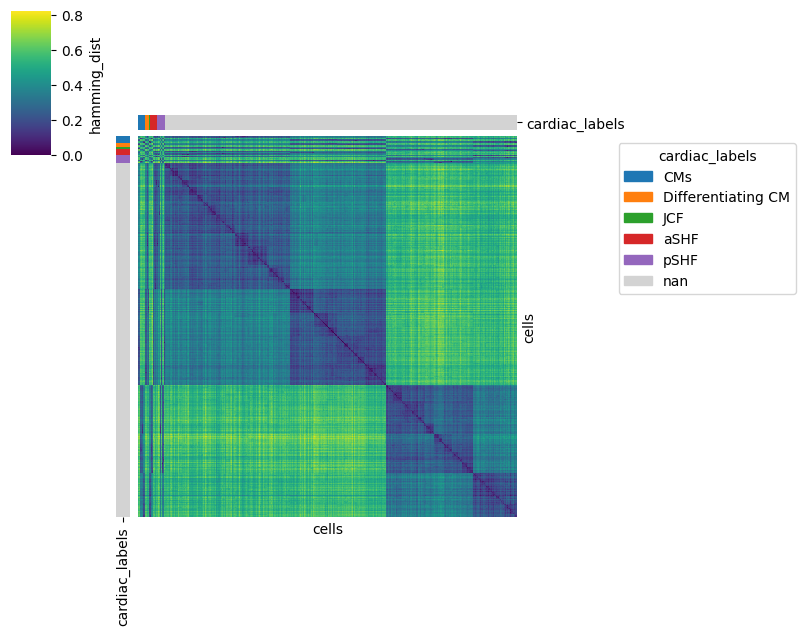

In [46]:
g = plot_distance_heatmap_grouped(tdata, groupby="cardiac_labels", distance_key='hamming_dist', palette=palette)

In [27]:
tdata_cardiac_subset = tdata[tdata.obs['cardiac_labels'].notna()]

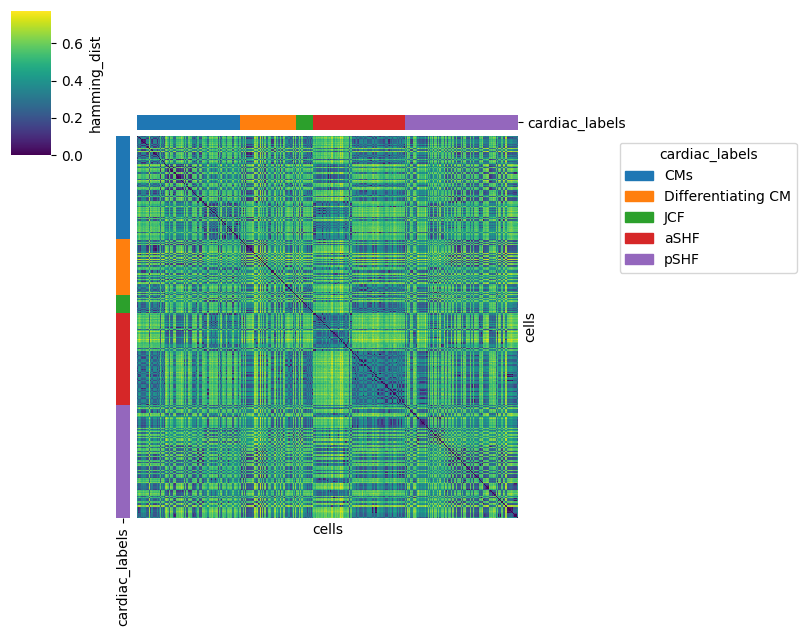

In [47]:
g_sub = plot_distance_heatmap_grouped(tdata_cardiac_subset, groupby="cardiac_labels", distance_key='hamming_dist', palette=palette,)

In [ ]:
mt.costs._costs._scaled_hamming_dist()

In [ ]:
mt.costs.BarcodeDistance()

In [21]:
lp = LineageProblem(tdata)

# In order to pass in cells that has no lineage barcode detection, the _scaled_hamming_dist() function was modified st instead of returning a 
# Error, a large distance was returned. Note, this is one way to solve this problem of no detection. Worth thinking and trying other solutions
lp = lp.prepare(
    time_key="time",
    lineage_attr={"attr": "obsm", "key": "characters"},
    cost={"x": "barcode_distance"},
)

KeyError: 'xy'

#### Creating a Obs for numeric time


In [71]:
# need to make a time variable that is categorical with numeric based
merged_tdata.obs["time"] = pd.to_numeric(merged_tdata.obs['stage'].str[1:]).astype('category')

In [72]:
merged_tdata.obs['time'].unique()

[8.5]
Categories (1, float64): [8.5]

#### Harmony Integration

In [81]:
import harmonypy as hm

# Run the algorithm directly
harmony_out = hm.run_harmony(merged_tdata.obsm["X_pca"], merged_tdata.obs, "embryo")

# Save the matrix directly (do NOT use .T)
merged_tdata.obsm["X_pca_harmony"] = harmony_out.Z_corr

2026-07-08 10:44:53,930 - harmonypy - INFO - Running Harmony
Running Harmony
2026-07-08 10:44:53,931 - harmonypy - INFO -   Parameters:
  Parameters:
2026-07-08 10:44:53,932 - harmonypy - INFO -     max_iter_harmony: 10
    max_iter_harmony: 10
2026-07-08 10:44:53,933 - harmonypy - INFO -     max_iter_kmeans: 4
    max_iter_kmeans: 4
2026-07-08 10:44:53,933 - harmonypy - INFO -     epsilon_cluster: 0.001
    epsilon_cluster: 0.001
2026-07-08 10:44:53,934 - harmonypy - INFO -     epsilon_harmony: 0.01
    epsilon_harmony: 0.01
2026-07-08 10:44:53,935 - harmonypy - INFO -     nclust: 100
    nclust: 100
2026-07-08 10:44:53,935 - harmonypy - INFO -     block_size: 0.05
    block_size: 0.05
2026-07-08 10:44:53,936 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
    lamb: dynamic (alpha=0.2)
2026-07-08 10:44:53,937 - harmonypy - INFO -     theta: [2. 2. 2.]
    theta: [2. 2. 2.]
2026-07-08 10:44:53,937 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
    sigma: [0.1 0.1 0.1 0.1 0

In [82]:
sc.pp.neighbors(merged_tdata, key_added="neighbor_harmony")
sc.tl.umap(merged_tdata, key_added="X_Umap_harmony", neighbors_key='neighbor_harmony')

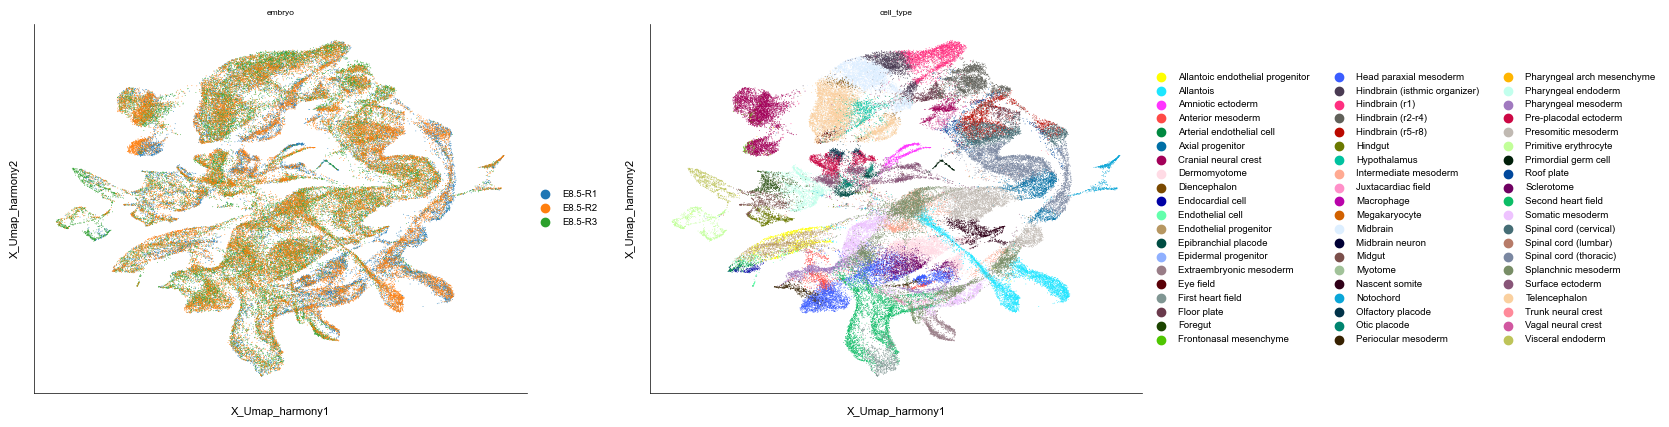

: 

: 

In [ ]:
sc.pl.embedding(merged_tdata, basis = 'X_Umap_harmony', color = ['embryo','cell_type'])

#### Leiden 

#### Saving the processed tdata

### Moslin Lineage Problem

In [27]:

lp = LineageProblem(merged_tdata)

# In order to pass in cells that has no lineage barcode detection, the _scaled_hamming_dist() function was modified st instead of returning a 
# Error, a large distance was returned. Note, this is one way to solve this problem of no detection. Worth thinking and trying other solutions
lp = lp.prepare(
    time_key="time",
    joint_attr="X_pca_fastRNA",
    lineage_attr={"attr": "obsm", "key": "X_characters", "cost": "barcode_distance"}, 
)

INFO     Computing barcode distance                                                                                
INFO     Computing barcode distance                                                                                


KeyboardInterrupt: 

In [26]:
lp.solve(epsilon=.1, alpha=.5, tau_a= 0.95, tau_b=.9) # Setting tau < 1 to allow for unbalanced transport. Setting tau_a higher than tau_b to reflect the fact that there is more proliferation than death in a developing embryo

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1342, 4498)].                                  


LineageProblem[(7.5, 8.0)]

# Checkpoint

In [ ]:
lp.save(output_data+"lp_three_days_trial_2.pkl", overwrite=True)

# Make tree for the first two time point

In [29]:
pwd

'/project/imoskowitz/yubin/Lineage_Tree_Construction'

In [34]:
tdatas

{'E7.5-R1': TreeData object with n_obs × n_vars = 1342 × 78258
     obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'depth'
     var: 'gene_ids', 'mito', 'chromosome'
     uns: 'cell_type_colors'
     obsm: 'X_scvi', 'X_umap', 'characters'
     obst: 'E7.5-R1-C1', 'E7.5-R1-C2',
 'E8.0-R1': TreeData object with n_obs × n_vars = 4498 × 78258
     obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'depth'
     var: 'gene_ids', 'mito', 'chromosome'
     obsm: 'X_scvi', 'X_umap', 'characters'
     obst: 'E8.0-R1-C1', 'E8.0-R1-C2', 'E8.0-R1-C3'}

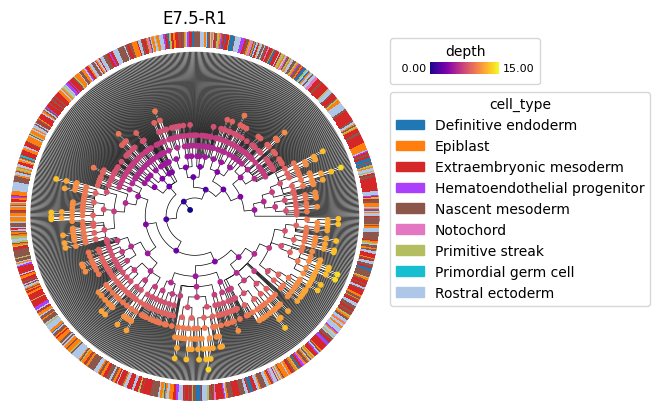

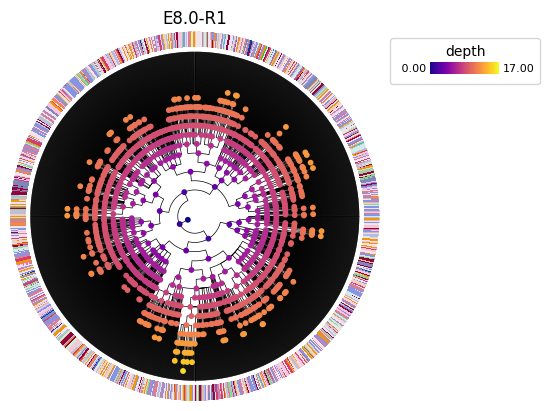

In [36]:
for k, v in tdatas.items():
    py.pp.add_depth(v)
    py.pl.branches(v, polar=True, extend_branches=True, tree=str(k)+"-C1")
    py.pl.nodes(v, color='depth', cmap="plasma")
    py.pl.annotation(v, keys='cell_type', cmap='viridis', width=.1)
    plt.title(k)

In [41]:
v.obs

,cell_subtype,capture,embryo,stage,type,total_counts,pe_counts,detection_rate,edit_frac,clone,phase,cell_type,germ_layer,lineage,tree,depth
E8.0-R1-T1-CTCCCTGGTGAGCGAT-1,Forebrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,19493.0,28.0,0.970588,0.480392,E8.0-R1-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,9.0
E8.0-R1-T1-GTGCGAGGTCAACTCG-1,Forebrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,18041.0,18.0,0.970588,0.480392,E8.0-R1-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,9.0
E8.0-R1-T1-TGGATGCTCATACTCC-1,Forebrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,16307.0,32.0,0.882353,0.559140,E8.0-R1-C1,G2/M,Forebrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,12.0
E8.0-R1-T1-CGCACGATCCGCGTAG-1,Hindbrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,12310.0,17.0,0.882353,0.537634,E8.0-R1-C1,G2/M,Hindbrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,12.0
E8.0-R1-T1-AAGGTTAAGTAACCTG-1,Forebrain,E8.0-R1-T1,E8.0-R1,E8.0,donor,19102.0,31.0,0.941176,0.505051,E8.0-R1-C1,S,Forebrain,Ectoderm,Neural ectoderm,E8.0-R1-C1,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E8.0-R1-T1-TGGGTGAAGTCAAGCC-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,28256.0,0.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,NaN
E8.0-R1-T1-TGGTCCTCACTCGGAA-1,Gut,E8.0-R1-T1,E8.0-R1,E8.0,donor,10322.0,17.0,0.735294,NaN,NaN,G2/M,Gut,Endoderm,Endoderm,NaN,NaN
E8.0-R1-T1-TGTAGCGCAATCGAGT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,16391.0,0.0,NaN,NaN,NaN,G2/M,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,NaN
E8.0-R1-T1-TGTCGATGTGCAATCT-1,Visceral endoderm,E8.0-R1-T1,E8.0-R1,E8.0,host,21732.0,1.0,NaN,NaN,NaN,S,Visceral endoderm,Endoderm,Extraembryonic endoderm,NaN,NaN
